In [74]:
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

boston_dataset = fetch_openml(name='boston', version=1)

boston = pd.DataFrame(boston_dataset.data, columns = boston_dataset.feature_names)
boston['MEDV'] = boston_dataset.target
boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [24]:
boston.shape

(506, 14)

In [26]:
boston.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [30]:
boston.shape[0]

506

In [33]:
boston[['CHAS', 'RM', 'AGE', 'RAD', 'MEDV']].head(n=30)

,CHAS,RM,AGE,RAD,MEDV
0,0,6.575,65.2,1,24.0
1,0,6.421,78.9,2,21.6
2,0,7.185,61.1,2,34.7
3,0,6.998,45.8,3,33.4
4,0,7.147,54.2,3,36.2
5,0,6.430,58.7,3,28.7
6,0,6.012,66.6,5,22.9
7,0,6.172,96.1,5,27.1
8,0,5.631,100.0,5,16.5
9,0,6.004,85.9,5,18.9


In [38]:
boston.describe(include='all').round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.00,506.00,506.00,506,506.00,506.00,506.00,506.00,506,506.00,506.00,506.00,506.00,506.00
unique,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,24,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,471,NaN,NaN,NaN,NaN,132,NaN,NaN,NaN,NaN,NaN
mean,3.61,11.36,11.14,NaN,0.55,6.28,68.57,3.80,NaN,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,NaN,0.12,0.70,28.15,2.11,NaN,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,NaN,0.38,3.56,2.90,1.13,NaN,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,NaN,0.45,5.89,45.02,2.10,NaN,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,NaN,0.54,6.21,77.50,3.21,NaN,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,NaN,0.62,6.62,94.07,5.19,NaN,666.00,20.20,396.22,16.96,25.00


In [39]:
boston['AGE'].describe()

count    506.000000
mean      68.574901
std       28.148861
min        2.900000
25%       45.025000
50%       77.500000
75%       94.075000
max      100.000000
Name: AGE, dtype: float64

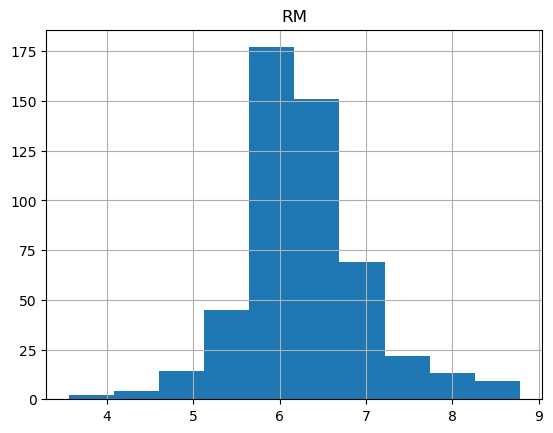

In [57]:
boston.hist(column='RM')
plt.show()

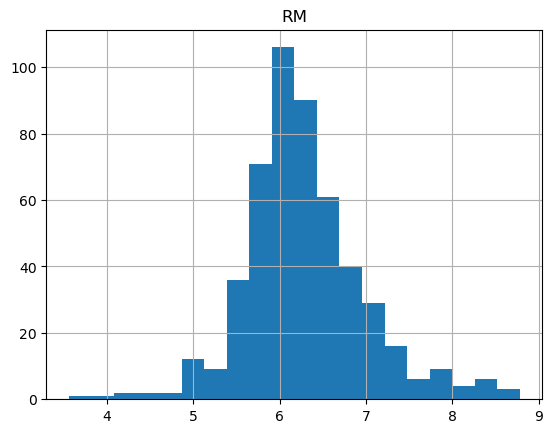

In [59]:
boston.hist(column='RM', bins=20)
plt.show()

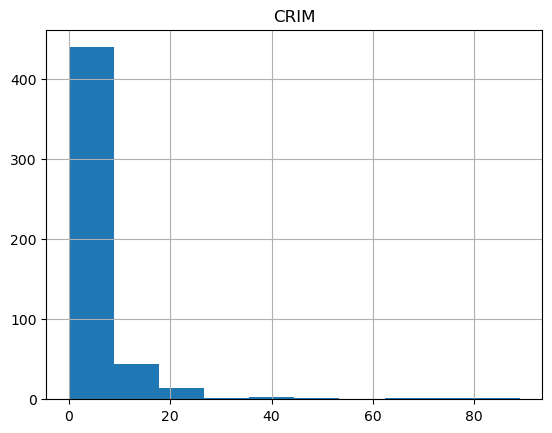

In [63]:
boston.hist(column='CRIM')
plt.show()

In [65]:
print(boston)
corr_matrix = boston.corr().round(2)
print(corr_matrix)

        CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  \
0    0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0   
1    0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0   
2    0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0   
3    0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0   
4    0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0   
..       ...   ...    ...  ...    ...    ...   ...     ...  ..    ...   
501  0.06263   0.0  11.93    0  0.573  6.593  69.1  2.4786   1  273.0   
502  0.04527   0.0  11.93    0  0.573  6.120  76.7  2.2875   1  273.0   
503  0.06076   0.0  11.93    0  0.573  6.976  91.0  2.1675   1  273.0   
504  0.10959   0.0  11.93    0  0.573  6.794  89.3  2.3889   1  273.0   
505  0.04741   0.0  11.93    0  0.573  6.030  80.8  2.5050   1  273.0   

     PTRATIO       B  LSTAT  MEDV  
0       15.3  396.90   4.98  24.0  
1       17.8  396.90   9.14  21.6  
2       17.8  3

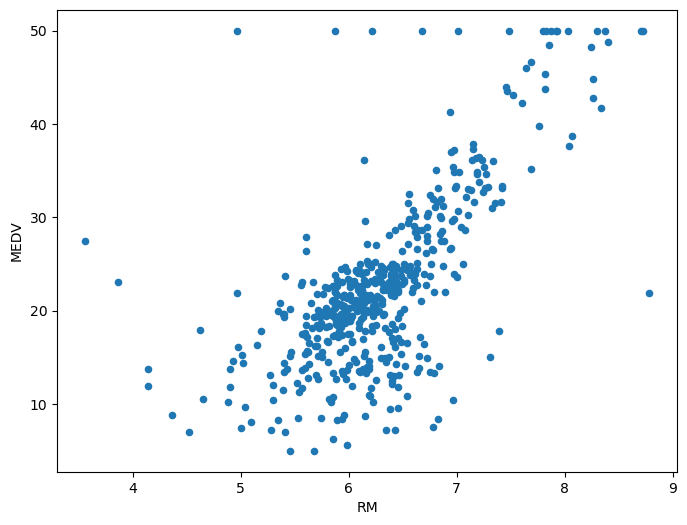

In [66]:
boston.plot(kind = 'scatter',
  x = 'RM',
  y = 'MEDV',
  figsize=(8,6))
plt.savefig("plot1.png")
plt.show()

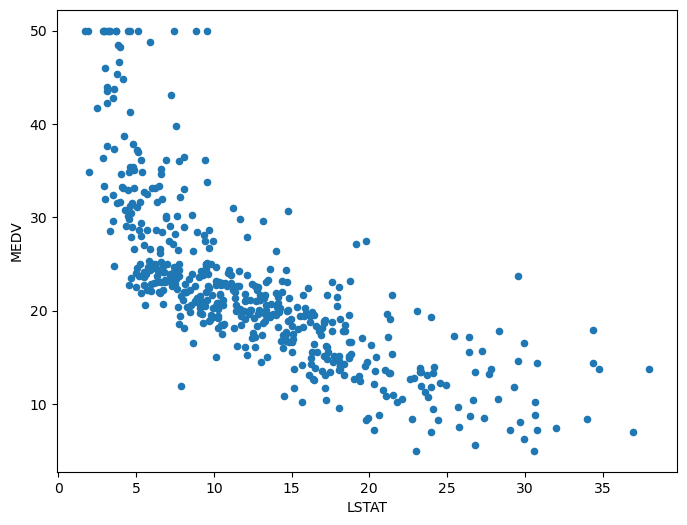

In [67]:
boston.plot(kind = 'scatter',
  x = 'LSTAT',
  y = 'MEDV',
  figsize=(8,6))
plt.savefig("plot1.png")
plt.show()

In [68]:
X = boston[['RM']]
print(X.shape)

(506, 1)


In [69]:
Y = boston['MEDV']
print(Y.shape)

(506,)


In [99]:
model = LinearRegression()
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
x = boston['RM']
y = boston['MEDV']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 1)
X.shape, Y.shape, x.shape, y.shape

((506, 1), (506,), (506,), (506,))

In [102]:
model = LinearRegression()
model.fit(X_train, Y_train)
model.intercept_.round(2), model.coef_.round(2)

(np.float64(-30.57), array([8.46]))

In [87]:
new_RM = np.array([6.5]).reshape(-1, 1)
model.predict(new_RM)

/home/pyjoek/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([24.42606323])

In [90]:
model.intercept_ + model.coef_*6.5

array([24.42606323])

In [104]:
y_test_prediction = model.predict(X_test)
y_test_prediction.shape
type(y_test_prediction)

numpy.ndarray

In [97]:
model.coef_

array([8.46109164])

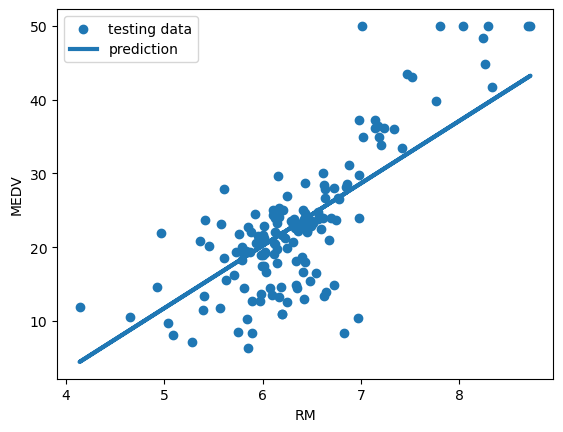

In [113]:
plt.scatter(X_test, Y_test, label='testing data')
plt.plot(X_test, y_test_prediction, label='prediction', linewidth=3)
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.legend(loc='upper left')
plt.show()